In [1]:
import pandas as pd
import polars as pl
import numpy as np
import os
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
import pickle

from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

import warnings
warnings.filterwarnings('ignore')
pd.options.display.max_columns = None

class CONFIG:
    seed = 42
    target_col = "responder_6"
    feature_cols = ["symbol_id", "time_id"] \
        + [f"feature_{idx:02d}" for idx in range(79)] \
        + [f"responder_{idx}_lag_1" for idx in range(9)]
    categorical_cols = []

/Users/johnny/Library/CloudStorage/OneDrive-Personal/py/JaneStreet2024/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train = pl.scan_parquet("training.parquet").collect().to_pandas()
valid = pl.scan_parquet("validation.parquet").collect().to_pandas()
train.shape, valid.shape

((8598744, 103), (13505536, 103))

In [3]:
train = pd.concat([train, valid]).reset_index(drop=True)
train.shape

(22104280, 103)

In [4]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
import numpy as np

X_train = train[ CONFIG.feature_cols ]
y_train = train[ CONFIG.target_col ]
w_train = train[ "weight" ]
X_valid = valid[ CONFIG.feature_cols ]
y_valid = valid[ CONFIG.target_col ]
w_valid = valid[ "weight" ]

def objective(trial):
    XGB_Params = {
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-4, 1e-1),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'subsample': trial.suggest_uniform('subsample', 0.5, 0.85), # may lead to overfitting
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-3, 10.0),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-3, 10.0),
        'random_state': CONFIG.seed,
        'tree_method': 'hist',
        # 'device': 'cpu',
    }

    model = XGBRegressor(**XGB_Params)
    model.fit(X_train, y_train, sample_weight=w_train, eval_set=[(X_valid, y_valid)], sample_weight_eval_set=[w_valid], verbose=False)
    
    y_pred_valid = model.predict(X_valid)
    valid_score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid)
    return valid_score

# Run optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

# Best parameters and score
print("Best trial:")
print("  Value: ", study.best_trial.value)
print("  Params: ")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")

[I 2024-11-12 16:03:39,487] A new study created in memory with name: no-name-f6950bf6-d6ed-486d-a030-e19fff183768
[I 2024-11-12 16:20:59,238] Trial 0 finished with value: 0.004369199275970459 and parameters: {'learning_rate': 0.00033083723831472294, 'max_depth': 9, 'n_estimators': 491, 'subsample': 0.7621872894875943, 'colsample_bytree': 0.8221788193123505, 'reg_alpha': 4.747854991602321, 'reg_lambda': 0.001831494887807882}. Best is trial 0 with value: 0.004369199275970459.
[I 2024-11-12 16:28:34,913] Trial 1 finished with value: 0.0028641223907470703 and parameters: {'learning_rate': 0.0006485804258599355, 'max_depth': 7, 'n_estimators': 225, 'subsample': 0.6255566974203635, 'colsample_bytree': 0.9211645285542911, 'reg_alpha': 0.04149507677227269, 'reg_lambda': 0.034927072388177945}. Best is trial 0 with value: 0.004369199275970459.
[I 2024-11-12 16:35:15,532] Trial 2 finished with value: 0.014612078666687012 and parameters: {'learning_rate': 0.005025166036900178, 'max_depth': 8, 'n_e

Best trial:
  Value:  0.21664726734161377
  Params: 
    learning_rate: 0.08893842720138131
    max_depth: 10
    n_estimators: 370
    subsample: 0.5082792114268431
    colsample_bytree: 0.7310192525373048
    reg_alpha: 1.3041375057650753
    reg_lambda: 0.005267852883680882


In [5]:
def get_model(seed):
    # XGBoost parameters
    XGB_Params = {
        'learning_rate': 0.08893842720138131,
        'max_depth': 10,
        'n_estimators': 370,
        'subsample': 0.5082792114268431,
        'colsample_bytree': 0.7310192525373048,
        'reg_alpha': 1.3041375057650753,
        'reg_lambda': 0.005267852883680882,
        'random_state': seed,
        'tree_method': 'hist',
    }
    
    XGB_Model = XGBRegressor(**XGB_Params)
    return XGB_Model

In [6]:
model = get_model(CONFIG.seed)
model.fit( X_train, y_train, sample_weight=w_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7310192525373048, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.08893842720138131, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=370, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [7]:
y_pred_train1 = model.predict(X_train.iloc[:X_train.shape[0]//2])
y_pred_train2 = model.predict(X_train.iloc[X_train.shape[0]//2:])
train_score = r2_score(y_train, np.concatenate([y_pred_train1, y_pred_train2], axis=0), sample_weight=w_train )
train_score

0.2099124789237976

In [8]:
y_pred_valid = model.predict(X_valid)
valid_score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
valid_score

0.21664726734161377

In [9]:
y_means = { symbol_id : -1 for symbol_id in range(39) }
for symbol_id, gdf in train[["symbol_id", CONFIG.target_col]].groupby("symbol_id"):
    y_mean = gdf[ CONFIG.target_col ].mean()
    y_means[symbol_id] = y_mean
    print(f"symbol_id = {symbol_id}, y_means = {y_mean:.5f}")

symbol_id = 0, y_means = -0.00098
symbol_id = 1, y_means = -0.00341
symbol_id = 2, y_means = -0.00397
symbol_id = 3, y_means = 0.00723
symbol_id = 4, y_means = 0.01000
symbol_id = 5, y_means = -0.00063
symbol_id = 6, y_means = 0.00344
symbol_id = 7, y_means = 0.00040
symbol_id = 8, y_means = 0.00008
symbol_id = 9, y_means = -0.03597
symbol_id = 10, y_means = 0.00631
symbol_id = 11, y_means = 0.00323
symbol_id = 12, y_means = -0.00015
symbol_id = 13, y_means = -0.01423
symbol_id = 14, y_means = -0.00069
symbol_id = 15, y_means = 0.00938
symbol_id = 16, y_means = 0.00351
symbol_id = 17, y_means = 0.00097
symbol_id = 18, y_means = 0.00169
symbol_id = 19, y_means = 0.01435
symbol_id = 20, y_means = 0.00564
symbol_id = 21, y_means = 0.00550
symbol_id = 22, y_means = -0.00096
symbol_id = 23, y_means = 0.01218
symbol_id = 24, y_means = -0.00468
symbol_id = 25, y_means = -0.01868
symbol_id = 26, y_means = -0.00052
symbol_id = 27, y_means = -0.00559
symbol_id = 28, y_means = -0.00516
symbol_id 

In [10]:
cv_detail = { symbol_id : 0 for symbol_id in range(39) }
for symbol_id, gdf in valid.groupby("symbol_id"):
    X_valid = gdf[ CONFIG.feature_cols ]
    y_valid = gdf[ CONFIG.target_col ]
    w_valid = gdf[ "weight" ]
    y_pred_valid = model.predict(X_valid)
    score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
    cv_detail[symbol_id] = score
    
    print(f"symbol_id = {symbol_id}, score = {score:.5f}")

symbol_id = 0, score = 0.22914
symbol_id = 1, score = 0.21924
symbol_id = 2, score = 0.19278
symbol_id = 3, score = 0.22289
symbol_id = 4, score = 0.19423
symbol_id = 5, score = 0.26744
symbol_id = 6, score = 0.11249
symbol_id = 7, score = 0.22866
symbol_id = 8, score = 0.18751
symbol_id = 9, score = 0.30802
symbol_id = 10, score = 0.13323
symbol_id = 11, score = 0.17911
symbol_id = 12, score = 0.23381
symbol_id = 13, score = 0.25182
symbol_id = 14, score = 0.14034
symbol_id = 15, score = 0.16160
symbol_id = 16, score = 0.22290
symbol_id = 17, score = 0.21120
symbol_id = 18, score = 0.19746
symbol_id = 19, score = 0.32060
symbol_id = 20, score = 0.16591
symbol_id = 21, score = 0.13883
symbol_id = 22, score = 0.11918
symbol_id = 23, score = 0.16283
symbol_id = 24, score = 0.15616
symbol_id = 25, score = 0.26008
symbol_id = 26, score = 0.20110
symbol_id = 27, score = 0.30797
symbol_id = 28, score = 0.21556
symbol_id = 29, score = 0.21902
symbol_id = 30, score = 0.28247
symbol_id = 31, sc

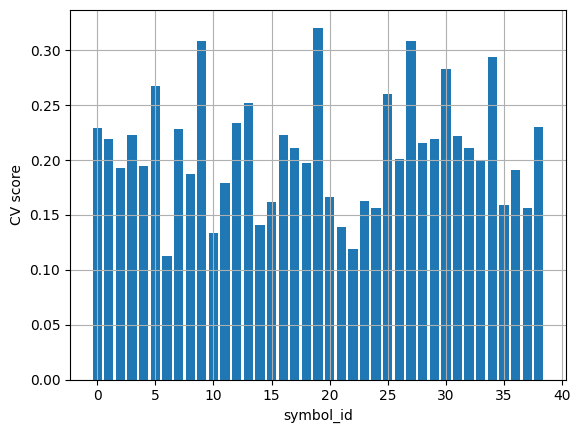

In [11]:
sids = list(cv_detail.keys())
plt.bar(sids, [cv_detail[sid] for sid in sids])
plt.grid()
plt.xlabel("symbol_id")
plt.ylabel("CV score")
plt.show()

In [12]:
result = {
    "model" : model,
    "cv" : valid_score,
    "cv_detail" : cv_detail,
    "y_mean" : y_means,
}
with open("result.pkl", "wb") as fp:
    pickle.dump(result, fp)